# Tarea 2 — Análisis Exploratorio de Datos
## Práctica: Comportamiento del SPEI 💳

Analizamos la serie **CF891** de Banxico: número de operaciones tercero a tercero en SPEI (rango "mayores a 8 mil y menores a 300 mil"), diaria, de 2009 a 2026.

In [ ]:
# Importamos las librerias que se van a usar a lo largo del notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

---
## Inciso 1: Valores ausentes e imputación

**Objetivo:** Revisar si existen valores ausentes en la serie diaria, entender por qué existen, y decidir si conviene imputarlos a nivel diario o mensual.

---
### ¿Qué significa la variable "SF336087"?

**Objetivo:** Antes de realizar el análisis correspondiente, entender qué representa la columna del dataset

La variable **SF336087** corresponde a una serie estadística publicada por el **Banco de México (Banxico)** dentro de las estadísticas del **Sistema de Pagos Electrónicos Interbancarios (SPEI)**.

Esta variable registra el **número diario de operaciones SPEI realizadas entre terceros** (es decir, entre personas o empresas distintas) cuyo **monto es mayor a 8,000 y menor a 300,000 pesos**.

Cada observación representa el total de transferencias efectuadas durante un día específico, por lo que se trata de una **serie de tiempo con periodicidad diaria**. La información se expresa como un **flujo**, es decir, la cantidad de operaciones realizadas en cada fecha y no un valor acumulado.

La variable **SF336087** permite observar cómo ha cambiado con el tiempo el número de transferencias SPEI entre terceros por montos mayores a 8,000 y menores a 300,000 pesos, así como identificar tendencias, patrones y posibles variaciones en su comportamiento diario.

#### Paso 1. Cargar los datos

In [ ]:
# Leer el archivo
df = pd.read_csv(
    "/content/Consulta_20260725-122309786.csv",
    encoding="latin-1",
    skiprows=18 #a partir del renglon 18 comienza la información a analizar.
)

# Verificar que se cargó correctamente
print(df.shape)
df.head()

(6410, 2)


,Fecha,SF336087
0,01/01/2009,N/E
1,02/01/2009,39578
2,03/01/2009,N/E
3,04/01/2009,N/E
4,05/01/2009,59840


In [ ]:
#Definimos el nombre de las columnas

df.columns = ["Fecha", "Operaciones"]

df.head()

,Fecha,Operaciones
0,01/01/2009,N/E
1,02/01/2009,39578
2,03/01/2009,N/E
3,04/01/2009,N/E
4,05/01/2009,59840


In [ ]:
#Convertimos en formato datetime64[ns]
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True) ##formato de méxico, no USA

#Reemplazamos todos los valores "N/E" a NaN
df["Operaciones"] = df["Operaciones"].replace("N/E", np.nan)
df["Operaciones"] = pd.to_numeric(df["Operaciones"])

In [ ]:
# Contamos y calculamos el PORCENTAJE de valores ausentes por columna

print("Valores ausentes:", df["Operaciones"].isna().sum())
print("Valores totales:",df["Operaciones"].shape[0])
porcentaje = df["Operaciones"].isna().mean()*100

print(f"Porcentaje de datos faltantes: {porcentaje:.2f}%")

Valores ausentes: 644
Valores totales: 6410
Porcentaje de datos faltantes: 10.05%


In [ ]:
# Cantidad de valores ausentes por año
faltantes_anuales = (
    df.groupby(df["Fecha"].dt.year)["Operaciones"]
      .apply(lambda x: x.isna().sum())
      .rename("Total nulos")
)

# Filtrar únicamente los registros con valores nulos
nulos = df[df["Operaciones"].isna()].copy()

# Traducir los días de la semana
dias = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

nulos["Día"] = nulos["Fecha"].dt.day_name().map(dias)
nulos["Año"] = nulos["Fecha"].dt.year

# Tabla de nulos por año y día
dias_nulos = (
    nulos.groupby(["Año", "Día"])
         .size()
         .unstack(fill_value=0)
)

# Orden correcto de los días
orden = ["Lunes", "Martes", "Miércoles", "Jueves",
         "Viernes", "Sábado", "Domingo"]
dias_nulos = dias_nulos.reindex(columns=orden)

# Union de tablas
resumen = faltantes_anuales.to_frame().join(dias_nulos)

print("=== Valores nulos por año ===")
print(resumen.head(8))

# ---------------------------------------------------
# Total de nulos por día de la semana
# ---------------------------------------------------
total_dias = (
    nulos["Día"]
    .value_counts()
    .reindex(orden, fill_value=0)
    .rename("Total")
)

print("\n=== Total de valores nulos por día de la semana ===")
print(total_dias.to_frame())

=== Valores nulos por año ===
       Total nulos  Lunes  Martes  Miércoles  Jueves  Viernes  Sábado  Domingo
Fecha                                                                         
2009           112    4.0     0.0        1.0     2.0      3.0    52.0     50.0
2010           105    3.0     1.0        0.0     2.0      3.0    48.0     48.0
2011           107    4.0     0.0        1.0     1.0      2.0    50.0     49.0
2012           107    3.0     2.0        1.0     1.0      2.0    46.0     52.0
2013           104    2.0     0.0        2.0     1.0      1.0    49.0     49.0
2014           105    1.0     1.0        0.0     3.0      1.0    50.0     49.0
2015             4    0.0     0.0        0.0     0.0      0.0     2.0      2.0
2016             0    NaN     NaN        NaN     NaN      NaN     NaN      NaN

=== Total de valores nulos por día de la semana ===
           Total
Día             
Lunes         17
Martes         4
Miércoles      5
Jueves        10
Viernes       12
Sábado  

Hasta este punto del análisis se observa que 596 de los 644 valores ausentes **(92.5 %)** corresponden a sábados y domingos, lo que evidencia que los datos faltantes **no se distribuyen de manera aleatoria**, sino que siguen un patrón sistemático. Además, estos valores ausentes **se concentran casi por completo en el periodo comprendido entre 2009 y 2014**, donde cada año presenta entre 104 y 112 registros faltantes. A partir de 2015, los valores ausentes se reducen prácticamente a cero y, **desde 2016, la serie ya no presenta datos faltantes.**

Este comportamiento coincide con la forma en que Banco de México publicaba la información del SPEI durante esos años. **Entre 2009 y 2014, Banxico no reportaba el número de operaciones correspondientes a los fines de semana**, por lo que los registros de sábados y domingos aparecen como N/E, generando un patrón de ausencia sistemático y predecible. **A partir de 2015, la política de publicación cambió** y comenzaron a difundirse también las cifras de los fines de semana, lo que explica la desaparición casi total de los valores ausentes.

En consecuencia, los valores faltantes observados en esta serie no corresponden a pérdidas aleatorias de información, sino a una característica propia de la publicación de los datos durante los primeros años del periodo analizado.

### Paso 2. Decidir que hacer con los ausentes ¿Imputación de manera diaria o de manera agrupada mensual?

Una vez identificado que la mayoría de los valores ausentes se concentra de manera sistemática en los fines de semana entre 2009 y 2014, el siguiente paso consiste en determinar cuál es la estrategia más adecuada para tratarlos. Para ello, se analizarán dos alternativas: **realizar la imputación directamente sobre la serie diaria o agrupar primero las observaciones por mes y posteriormente tratar los valores faltantes que permanezcan.** Ambos procedimientos serán evaluados por separado, considerando cómo afectan la forma de la serie, su tendencia y la interpretación de los resultados. Finalmente, se compararán las ventajas y limitaciones de cada alternativa con el propósito de seleccionar aquella que conserve mejor el comportamiento original de los datos y resulte más conveniente para el análisis posterior."

#### Preparación e imputación diaria

In [ ]:
# Preparación e imputación diaria

# Ordenar por fecha y crear una copia
df_diario = df.sort_values("Fecha").copy()

# Identificar los registros que originalmente eran nulos
df_diario["Fue_imputado"] = df_diario["Operaciones"].isna()

# Crear una nueva columna con la interpolación lineal
df_diario["Operaciones_imputadas"] = (
    df_diario["Operaciones"]
    .interpolate(method="linear")
)

# Verificar el resultado
print(
    "Valores ausentes antes de la imputación:",
    df_diario["Operaciones"].isna().sum()
)

print(
    "Valores ausentes después de la imputación:",
    df_diario["Operaciones_imputadas"].isna().sum()
)

Valores ausentes antes de la imputación: 644
Valores ausentes después de la imputación: 1


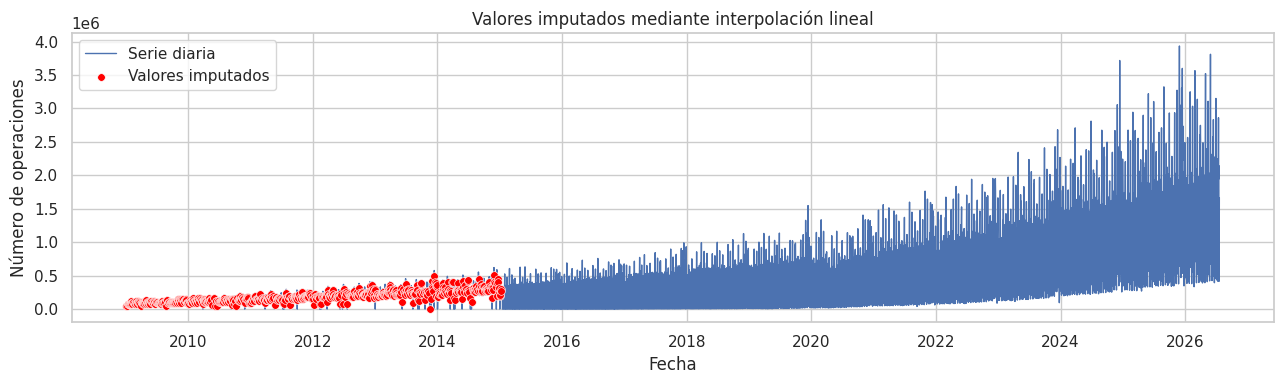

In [ ]:
# Valores imputados

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(
    data=df_diario,
    x="Fecha",
    y="Operaciones_imputadas",
    linewidth=1,
    label="Serie diaria",
    ax=ax
)
datos_imputados = df_diario[df_diario["Fue_imputado"]]

sns.scatterplot(
    data=datos_imputados,
    x="Fecha",
    y="Operaciones_imputadas",
    color="red",
    s=30,
    label="Valores imputados",
    zorder=3,
    ax=ax
)

ax.set_title("Valores imputados mediante interpolación lineal")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de operaciones")

ax.legend()
plt.tight_layout()
plt.show()

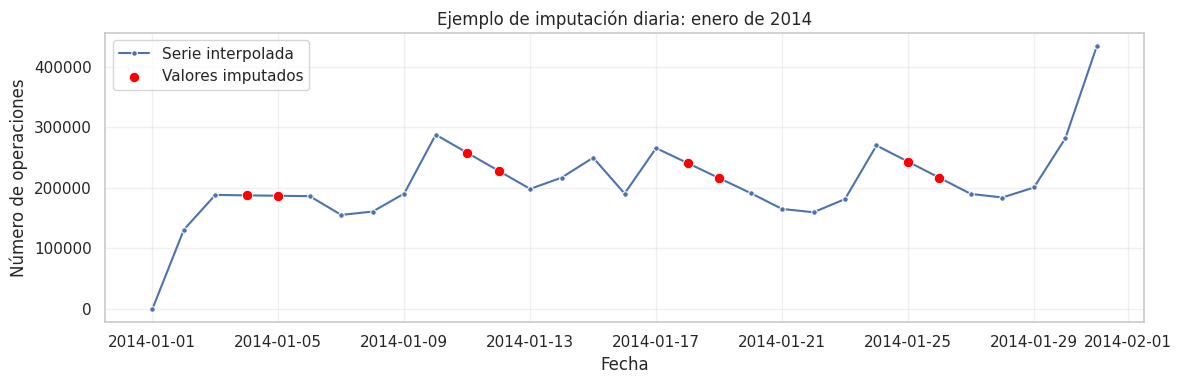

In [ ]:
# Ejemplo de imputación: enero de 2014

enero_2014 = (
    (df_diario["Fecha"] >= "2014-01-01") &
    (df_diario["Fecha"] < "2014-02-01")
)

datos_enero = df_diario.loc[enero_2014].copy()
imputados_enero = datos_enero[datos_enero["Fue_imputado"]]

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(
    data=datos_enero,
    x="Fecha",
    y="Operaciones_imputadas",
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="Serie interpolada",
    ax=ax
)

sns.scatterplot(
    data=imputados_enero,
    x="Fecha",
    y="Operaciones_imputadas",
    color="red",
    s=55,
    label="Valores imputados",
    zorder=3,
    ax=ax
)

ax.set_title("Ejemplo de imputación diaria: enero de 2014")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de operaciones")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

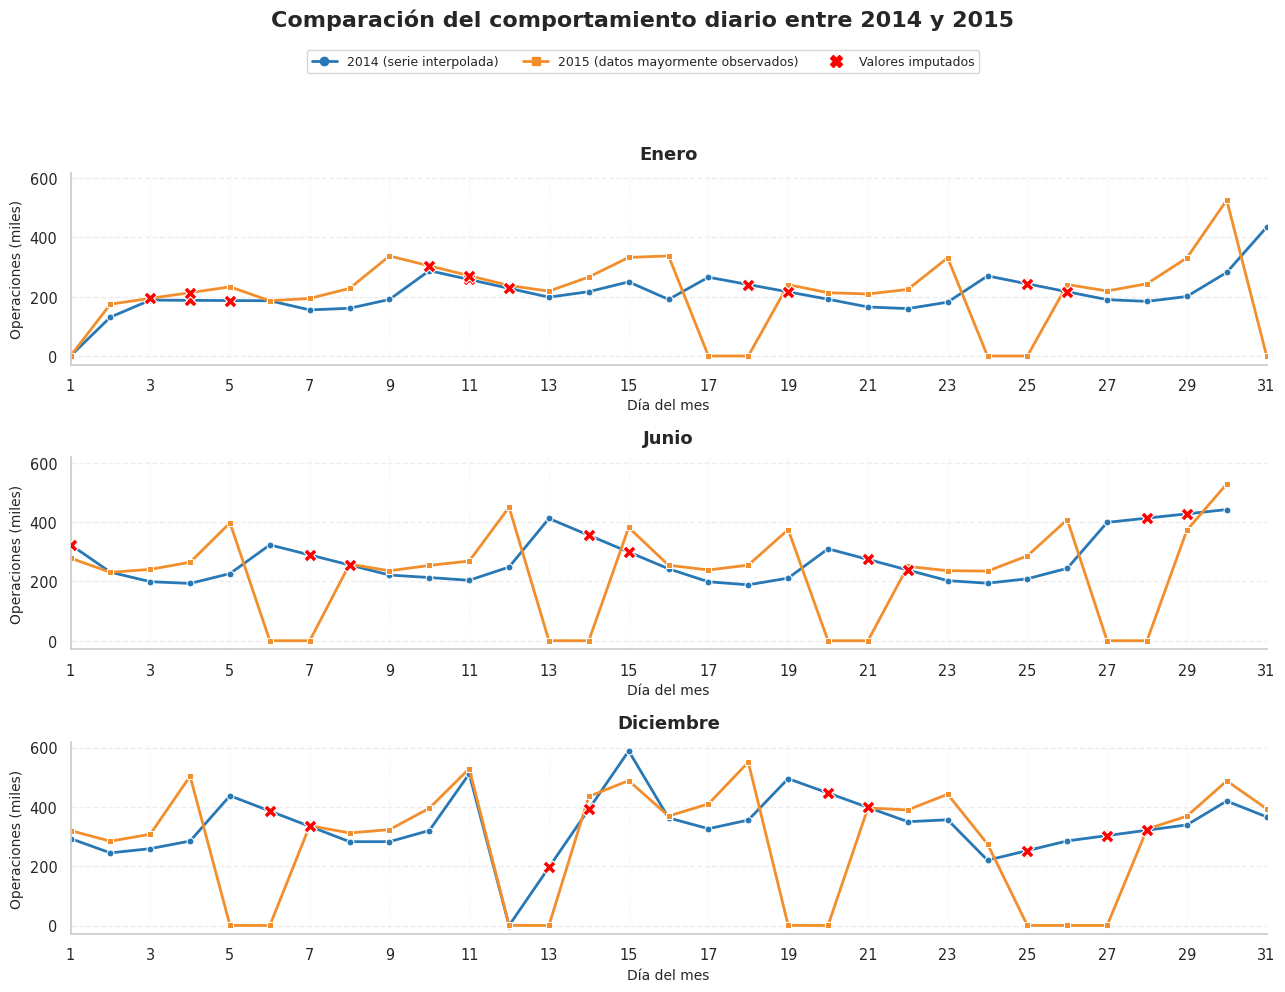

In [ ]:
# Comparación entre 2014 y 2015

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=0.95
)

meses = {
    1: "Enero",
    6: "Junio",
    12: "Diciembre"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(13, 10),
    sharex=False,
    sharey=True
)

for ax, (numero_mes, nombre_mes) in zip(axes, meses.items()):

    datos_2014 = df_diario[
        (df_diario["Fecha"].dt.year == 2014) &
        (df_diario["Fecha"].dt.month == numero_mes)
    ].copy()

    datos_2015 = df_diario[
        (df_diario["Fecha"].dt.year == 2015) &
        (df_diario["Fecha"].dt.month == numero_mes)
    ].copy()

    datos_2014["Día"] = datos_2014["Fecha"].dt.day
    datos_2015["Día"] = datos_2015["Fecha"].dt.day

    datos_2014["Operaciones_miles"] = (
        datos_2014["Operaciones_imputadas"] / 1000
    )

    datos_2015["Operaciones_miles"] = (
        datos_2015["Operaciones_imputadas"] / 1000
    )

    # Serie de 2014
    sns.lineplot(
        data=datos_2014,
        x="Día",
        y="Operaciones_miles",
        marker="o",
        markersize=5,
        linewidth=2,
        color="#2878B5",
        ax=ax
    )

    # Serie de 2015
    sns.lineplot(
        data=datos_2015,
        x="Día",
        y="Operaciones_miles",
        marker="s",
        markersize=5,
        linewidth=2,
        color="#F28E2B",
        ax=ax
    )

    # Valores imputados de 2014
    sns.scatterplot(
        data=datos_2014[datos_2014["Fue_imputado"]],
        x="Día",
        y="Operaciones_miles",
        color="red",
        marker="X",
        s=90,
        edgecolor="white",
        linewidth=0.8,
        zorder=5,
        ax=ax
    )

    # Valores imputados de 2015
    sns.scatterplot(
        data=datos_2015[datos_2015["Fue_imputado"]],
        x="Día",
        y="Operaciones_miles",
        color="red",
        marker="X",
        s=90,
        edgecolor="white",
        linewidth=0.8,
        zorder=5,
        ax=ax
    )

    ax.set_title(
        nombre_mes,
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel("Día del mes", fontsize=10)
    ax.set_ylabel("Operaciones (miles)", fontsize=10)

    ax.set_xlim(1, 31)
    ax.set_xticks(range(1, 32, 2))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.20
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:,.0f}")
    )

    sns.despine(ax=ax)

fig.suptitle(
    "Comparación del comportamiento diario entre 2014 y 2015",
    fontsize=16,
    fontweight="bold",
    y=0.99
)

leyenda = [
    Line2D(
        [0], [0],
        color="#2878B5",
        marker="o",
        linewidth=2,
        markersize=6,
        label="2014 (serie interpolada)"
    ),
    Line2D(
        [0], [0],
        color="#F28E2B",
        marker="s",
        linewidth=2,
        markersize=6,
        label="2015 (datos mayormente observados)"
    ),
    Line2D(
        [0], [0],
        color="red",
        marker="X",
        linestyle="None",
        markersize=8,
        label="Valores imputados"
    )
]

fig.legend(
    handles=leyenda,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=3,
    frameon=True,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

#### Manera agrupada mensual

In [ ]:
# Preparación de imputación de manera agrupada mensual

serie_diaria = (
    df[["Fecha", "Operaciones"]]
    .sort_values("Fecha")
    .set_index("Fecha")
    .asfreq("D")
)

# La suma será NaN si existe al menos un NaN en el mes
mensual_estricto = (
    serie_diaria["Operaciones"]
    .resample("ME")
    .apply(lambda x: x.sum(min_count=len(x)))
    .rename("Total_mensual")
)

print(mensual_estricto.head(84))

print(
    "Meses con total mensual ausente:",
    mensual_estricto.isna().sum()
)

print(
    "Meses totales:",
    mensual_estricto.shape[0]
)

Fecha
2009-01-31          NaN
2009-02-28          NaN
2009-03-31          NaN
2009-04-30          NaN
2009-05-31          NaN
                ...    
2015-08-31    6614644.0
2015-09-30    6728854.0
2015-10-31    7140561.0
2015-11-30    6950291.0
2015-12-31    8647530.0
Freq: ME, Name: Total_mensual, Length: 84, dtype: float64
Meses con total mensual ausente: 73
Meses totales: 211


In [ ]:
# Cantidad de meses ausentes y meses totales
meses_ausentes = mensual_estricto.isna().sum()
meses_totales = mensual_estricto.shape[0]

# Porcentaje de meses ausentes
porcentaje_meses_ausentes = (
    meses_ausentes / meses_totales
) * 100

print("Meses con total mensual ausente:", meses_ausentes)
print("Meses totales:", meses_totales)

print(
    f"Porcentaje de meses ausentes: "
    f"{porcentaje_meses_ausentes:.2f}%"
)

Meses con total mensual ausente: 73
Meses totales: 211
Porcentaje de meses ausentes: 34.60%


Al realizar la agrupación mensual estricta, considerando que el total de un mes sea ausente cuando al menos uno de sus días contiene un valor `NaN`, se obtiene que más del 30 % de los meses de la serie no cuenta con un total mensual completo.

Esta alternativa no resulta viable, ya que sería necesario imputar más del 20 % de los valores de la tabla mensual. Una proporción tan elevada implicaría reconstruir una parte considerable de la serie y podría generar resultados demasiado dependientes del método de imputación utilizado, reduciendo la confiabilidad del análisis. Por esta razón, no es conveniente tratar los datos ausentes mediante una interpolación directa de los totales mensuales.


### Conclusión

Después de comparar las dos alternativas, se decidió tratar los valores ausentes directamente en la serie diaria. Sin embargo, no se utilizará la interpolación lineal, ya que este procedimiento genera valores artificiales para los sábados y domingos a partir de las observaciones cercanas, suponiendo un comportamiento continuo que no necesariamente corresponde con la operación real del SPEI.

La comparación entre 2014 y 2015 mostró que los valores estimados mediante interpolación para los fines de semana de 2014 presentan diferencias importantes respecto a los valores efectivamente observados durante 2015. Por lo tanto, la interpolación podría modificar el comportamiento original de la serie y sobreestimar el número de operaciones realizadas durante los primeros años.

Además, Banco de México señala que a partir de 2015 el SPEI cambió a un esquema de pagos que opera los siete días de la semana. Esto respalda que la concentración de valores N/E en sábados y domingos antes de ese año está relacionada con el esquema operativo vigente y no con pérdidas aleatorias de información.

Por estas razones, los valores ausentes serán sustituidos por cero, interpretándolos para efectos de este análisis como días sin actividad registrada dentro del esquema operativo anterior. De esta manera, no se generan cantidades estimadas que no estén respaldadas por información observada y se conserva el patrón histórico de funcionamiento de la serie. Esta decisión debe quedar documentada como un supuesto del análisis, ya que se está considerando que los registros N/E representan ausencia de operaciones registradas.

La agrupación mensual estricta también queda descartada, debido a que convierte más del 30 % de los meses en observaciones incompletas y obligaría a reconstruir una proporción considerable de la serie mensual.

In [ ]:
# Valores ausentes a ceros
df_diario = df.copy()
df_diario["Operaciones"] = df_diario["Operaciones"].fillna(0)

In [ ]:
#Comprobaciones

# Mostrar las primeras filas
print("Primeras filas del dataframe:")
display(df_diario.head())

# Comprobar valores nulos en todas las columnas
print("\nValores nulos por columna:")
print(df_diario.isna().sum())

# Comprobar el total de valores nulos del dataframe
print("\nTotal de valores nulos:", df_diario.isna().sum().sum())

Primeras filas del dataframe:


,Fecha,Operaciones
0,2009-01-01,0.0
1,2009-01-02,39578.0
2,2009-01-03,0.0
3,2009-01-04,0.0
4,2009-01-05,59840.0



Valores nulos por columna:
Fecha          0
Operaciones    0
dtype: int64

Total de valores nulos: 0


---
## Inciso 2: Agrupación mensual, componentes y comportamiento de la serie

**Objetivo:** Agrupar la serie a nivel mensual, separarla en sus componentes (tendencia, estacionalidad, residuo) y entender su comportamiento a lo largo del tiempo.

In [ ]:
# 2. Agrupar la serie a nivel mensual

df_mensual = (
    df_diario
    .sort_values("Fecha")
    .set_index("Fecha")
    .resample("ME")
    .agg(
        Operaciones=("Operaciones", "sum"),
        Dias_incluidos=("Operaciones", "count"),
        Dias_ausentes=("Operaciones", lambda x: x.isna().sum())
    )
    .reset_index()
)

# Crear columnas de año y mes
df_mensual["Año"] = df_mensual["Fecha"].dt.year
df_mensual["Mes"] = df_mensual["Fecha"].dt.month

# Ordenar las columnas
df_mensual = df_mensual[
    [
        "Fecha",
        "Año",
        "Mes",
        "Operaciones",
        "Dias_incluidos",
        "Dias_ausentes"
    ]
]

# Mostrar los primeros 12 meses
df_mensual.head(12)

,Fecha,Año,Mes,Operaciones,Dias_incluidos,Dias_ausentes
0,2009-01-31,2009,1,1460214.0,31,0
1,2009-02-28,2009,2,1484540.0,28,0
2,2009-03-31,2009,3,1697723.0,31,0
3,2009-04-30,2009,4,1671716.0,30,0
4,2009-05-31,2009,5,1624776.0,31,0
5,2009-06-30,2009,6,1829679.0,30,0
6,2009-07-31,2009,7,1960139.0,31,0
7,2009-08-31,2009,8,1808322.0,31,0
8,2009-09-30,2009,9,1873911.0,30,0
9,2009-10-31,2009,10,1980610.0,31,0


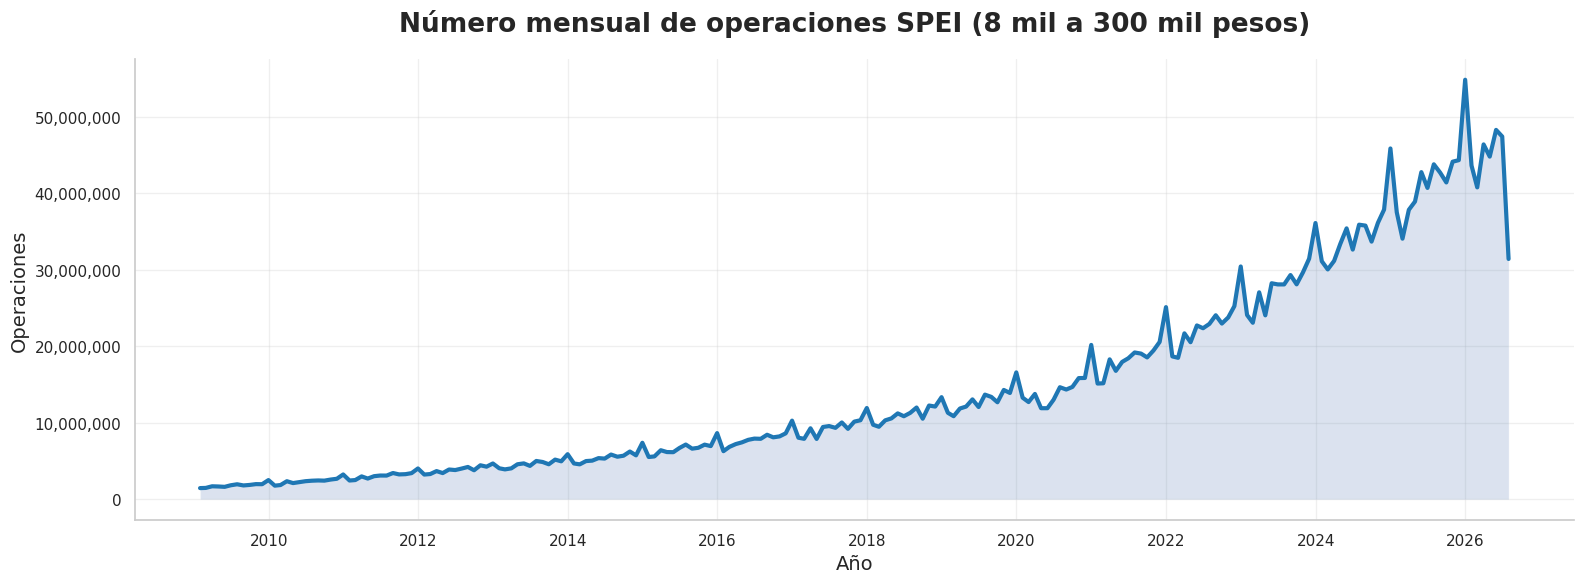

In [ ]:
# Gráficamos la serie:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(16,6))

sns.lineplot(
    data=df_mensual,
    x="Fecha",
    y="Operaciones",
    color="#1f77b4",
    linewidth=3,
    ax=ax
)

ax.fill_between(
    df_mensual["Fecha"],
    df_mensual["Operaciones"],
    alpha=0.20
)

ax.set_title(
    "Número mensual de operaciones SPEI (8 mil a 300 mil pesos)",
    fontsize=19,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Año", fontsize=14)
ax.set_ylabel("Operaciones", fontsize=14)

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

ax.grid(alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

Observamos en la serie una tendencia general creciente a lo largo de todo el periodo analizado. Pero analizandola más a fondo notamos que durante los primeros años, es decir desde 2009 a 2015, el incremento es relativamente gradual pero a partir de aproximadamente 2016/2017 muestra una aceleración y, desde 2020, el aumento se ve mucho más pronunciado, alcanzando picos muy altos durante 2025 y principios de 2026.

La gráfica muestra una **clara tendencia creciente** durante todo el periodo. El número de operaciones aumenta de forma continua y el crecimiento se vuelve más acelerado en los últimos años.

In [ ]:
# Convertimos la fecha en indice para para descomponerla y posteriormente analizar sus componentes

serie = (
    df_mensual
    .set_index("Fecha")["Operaciones"]
)

# Como lo agrupamos por meses, el periodo en la funcion de descomposición es 12

descomposicion = seasonal_decompose(
    serie,
    model="additive",
    period=12
)

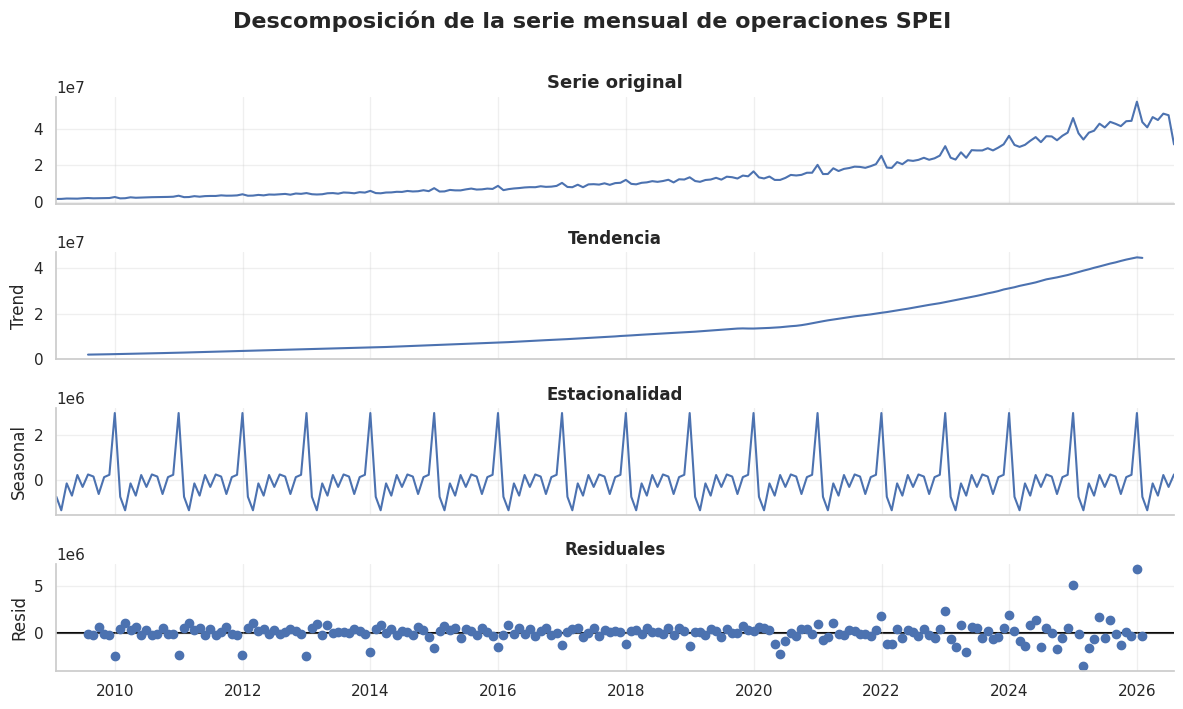

In [ ]:
# Gráficamos los componentes que nos dará 4 gráficas: la serie original, tendencia, espacionalidad y Residuales

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig = descomposicion.plot()

fig.set_size_inches(12, 7)

axes = fig.axes

axes[0].set_title("Serie original", fontsize=13, fontweight="bold")
axes[1].set_title("Tendencia", fontsize=12, fontweight="bold")
axes[2].set_title("Estacionalidad", fontsize=12, fontweight="bold")
axes[3].set_title("Residuales", fontsize=12, fontweight="bold")

for ax in axes:
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle(
    "Descomposición de la serie mensual de operaciones SPEI",
    fontsize=16,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

Analicemos cada componente:

*   Tendencia: Presenta un comportamiento creciente durante todo el periodo sin observarse periodos prolongados de disminución
*   Estacionalidad: La descomposición identifica un patrón estacional con periodicidad de 12 meses, es decir, existe una estacionalidad anual, es decir, cada año los meses presentan un comportamiento similar.
*   Residuales: Los puntos están distribuidos al rededor del cero por lo que podemos decir que no se aprecia un patrón sistemático pero vemos que despues de 2020 aparecen residuales de mayor magnitud

La componente estacional muestra un patrón que se repite cada año. Esto puede deberse a distintos factores, consideramos que el pago de aguinaldos al final del año, temporadas vacaionales, periodo de regreso a clases o mayor actividad economica en diciembre pueden ser los más importantes a tomar en cuenta.

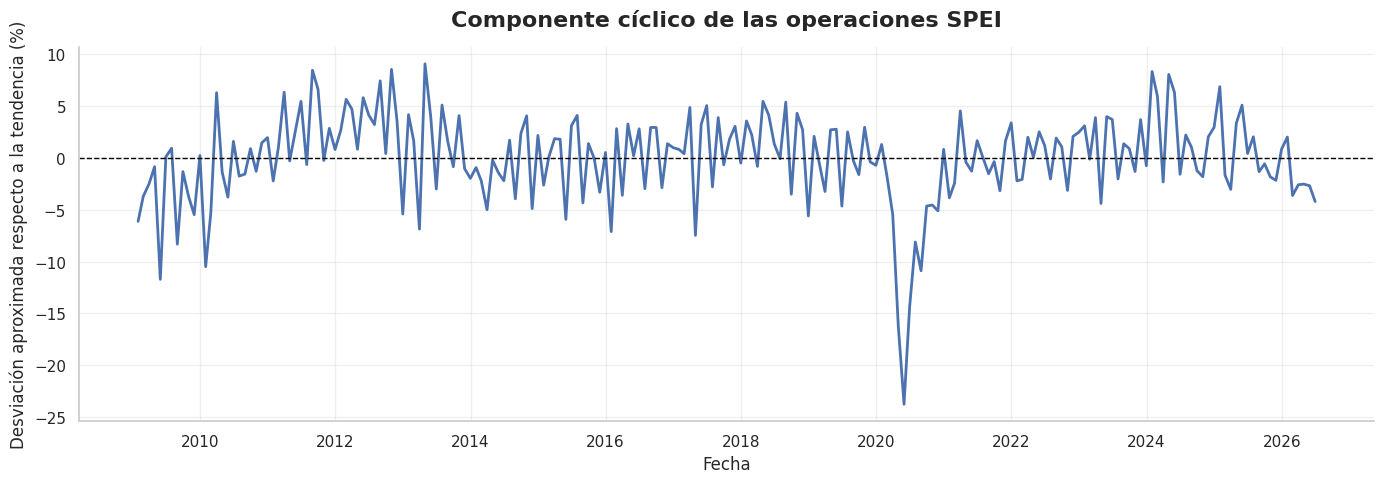

In [ ]:
# Estimamos el componente cíclico
# Identificamos la última fecha disponible
ultima_fecha = df_diario["Fecha"].max()

# Establecemos la fecha correspondiente al cierre de ese mes
fin_ultimo_mes = ultima_fecha.to_period("M").to_timestamp("M")

# Excluimos el último mes si todavía no está completo (principalmente por 2026)
if ultima_fecha.normalize() < fin_ultimo_mes.normalize():
    df_mensual_completo = df_mensual[
        df_mensual["Fecha"] < fin_ultimo_mes
    ].copy()
else:
    df_mensual_completo = df_mensual.copy()

# Trabajamos únicamente con meses completos para que no se vean caidas falsas en 2026
serie_hp = (
    df_mensual_completo
    .set_index("Fecha")["Operaciones"]
    .asfreq("ME")
)

# Aplicamos logaritmo para estabilizar la magnitud de las variaciones
serie_log = np.log(serie_hp)

# Obtenemos el componente estacional con una periodicidad de 12 meses
descomposicion_log = seasonal_decompose(
    serie_log,
    model="additive",
    period=12
)

# Eliminamos la estacionalidad para analizar las variaciones no estacionales
serie_desestacionalizada = (
    serie_log
    - descomposicion_log.seasonal
).dropna()

# Separamos la tendencia y el componente cíclico mediante el filtro Hodrick-Prescott
ciclo_hp, tendencia_hp = hpfilter(
    serie_desestacionalizada,
    lamb=129600
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    ciclo_hp.index,
    ciclo_hp * 100,
    linewidth=2
)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Componente cíclico de las operaciones SPEI",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel(
    "Desviación aproximada respecto a la tendencia (%)",
    fontsize=12
)

ax.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

* Componente cíclico: La serie presenta fluctuaciones por encima y por debajo de la tendencia, pero no se observa un ciclo que se repita de manera regular. La caída más importante ocurre en 2020, coincidiendo con el inicio de la pandemia. Posteriormente se observa una recuperación y, durante 2024 y 2025, varios meses se encuentran por encima de la tendencia.

In [ ]:
# Analizamos el patrón estacional por mes

promedio_mes = (
    df_mensual_completo
    .groupby("Mes")["Operaciones"]
    .mean()
)

print(promedio_mes)

Mes
1     1.344212e+07
2     1.292312e+07
3     1.450054e+07
4     1.411405e+07
5     1.531950e+07
6     1.502917e+07
7     1.389478e+07
8     1.400094e+07
9     1.342583e+07
10    1.439566e+07
11    1.471956e+07
12    1.770649e+07
Name: Operaciones, dtype: float64


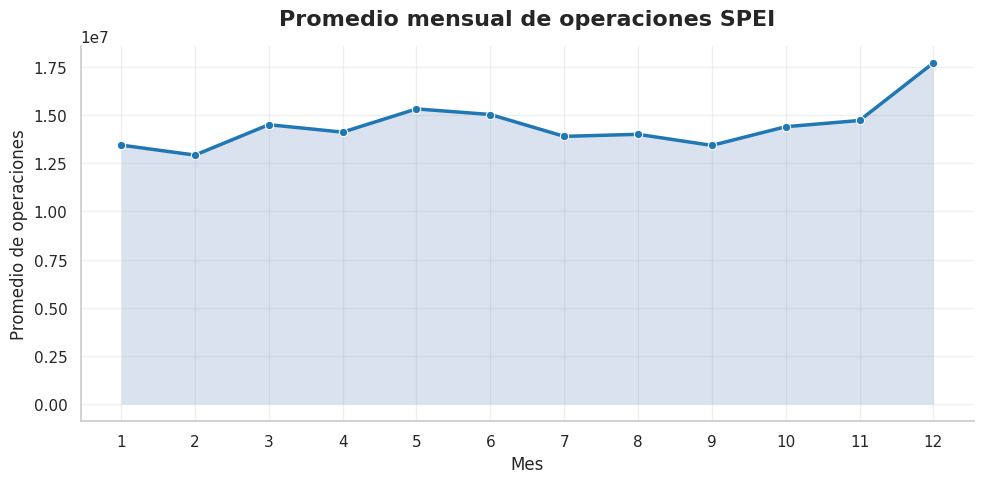

In [ ]:
# Gráficamos

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(10,5))

sns.lineplot(
    x=promedio_mes.index,
    y=promedio_mes.values,
    marker="o",
    linewidth=2.5,
    color="#1f77b4",
    ax=ax
)

ax.fill_between(
    promedio_mes.index,
    promedio_mes.values,
    alpha=0.20
)

ax.set_title(
    "Promedio mensual de operaciones SPEI",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Mes", fontsize=12)
ax.set_ylabel("Promedio de operaciones", fontsize=12)

ax.set_xticks(range(1, 13))

ax.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.show()

Al analizar el promedio de operaciones por mes observamos que la estacionalidad no es uniforme durante el año, como analizamos anteriormente, diciembre registra el mayor promedio mensual de operaciones, mientras que febrero presenta el menor promedio.
Adicionalmente, durante mayo y junio también se observa una actividad superior al promedio anual.

Este comportamiento confirma nuevamente la existencia de un patrón estacional que se repite año con año.

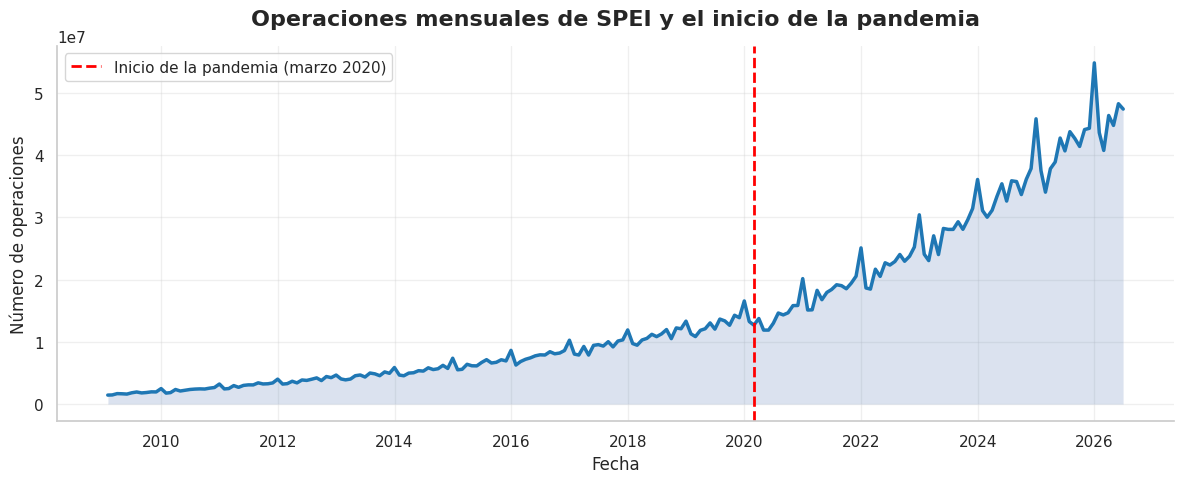

In [ ]:
# Analizamos el inicio de la pandemia

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(12,5))

sns.lineplot(
    data=df_mensual_completo,
    x="Fecha",
    y="Operaciones",
    color="#1f77b4",
    linewidth=2.5,
    ax=ax
)

ax.fill_between(
    df_mensual_completo["Fecha"],
    df_mensual_completo["Operaciones"],
    alpha=0.20
)

ax.axvline(
    x=pd.Timestamp("2020-03-01"),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Inicio de la pandemia (marzo 2020)"
)

ax.set_title(
    "Operaciones mensuales de SPEI y el inicio de la pandemia",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Número de operaciones", fontsize=12)

ax.grid(alpha=0.3)

ax.legend(loc="upper left", frameon=True)

sns.despine()

plt.tight_layout()

plt.show()

Observemos que alrededor de marzo de 2020 se registra una disminución temporal en el número de operaciones. Este descenso podemos asociarlo con la suspensión de actividades económicas provocada por la pandemia del covid-19.

Despues de esta caida, la serie se recupera y comienza a crecer de manera más acelerada. Consideramos que la pandemia probablemente incentivó el uso de medios de pago digitales por las restricciones de movilidad, el cierre de establecimientos y el aumento de compras por internet, lo que aumentó las transferencias electronicas.  

Recapitulando, no se observa un ciclo que se repita de forma exacta cada mes o cada año. Sin embargo, sí existe un patrón estacional: diciembre suele registrar más operaciones y febrero menos. También hay periodos en los que las operaciones se alejan de la tendencia, pero estos movimientos no ocurren de manera regular.

Por otro lado, si bien el crecimiento posterior a 2020 coincide con la pandemia donde hubo una adopción a los pagos digitales, es importante mencionar que el aumento comenzó desde años anteriores, sin embargo el fenomeno de la pandemia pudo haber funcionado como un acelerador de un proceso que ya estaba ocurriendo, es decir, más que ser la unica causa del crecimiento, fortaleció la tendencia existente.

---
## Inciso 3: Valores atípicos en la serie

**Objetivo:** Identificar meses con un número de operaciones mucho más alto o más bajo de lo que la tendencia y la estacionalidad predicen.

In [ ]:
# Usamos el residuo que ya calculamos en la descomposicion (Inciso 2) para
# encontrar los meses cuyo comportamiento se aleja mas de lo que la tendencia +
# estacionalidad predicen

residuales = descomposicion.resid.dropna()

top_altos = residuales.sort_values(ascending=False).head(5)
top_bajos = residuales.sort_values().head(5)

print("Meses con MAS operaciones de lo esperado:")
print(top_altos)
print()
print("Meses con MENOS operaciones de lo esperado:")
print(top_bajos)

Meses con MAS operaciones de lo esperado:
Fecha
2025-12-31    6.926203e+06
2024-12-31    5.122562e+06
2022-12-31    2.350140e+06
2023-12-31    1.940710e+06
2021-12-31    1.760494e+06
Name: resid, dtype: float64

Meses con MENOS operaciones de lo esperado:
Fecha
2025-02-28   -3.601393e+06
2012-12-31   -2.537699e+06
2009-12-31   -2.521500e+06
2010-12-31   -2.430610e+06
2011-12-31   -2.417739e+06
Name: resid, dtype: float64


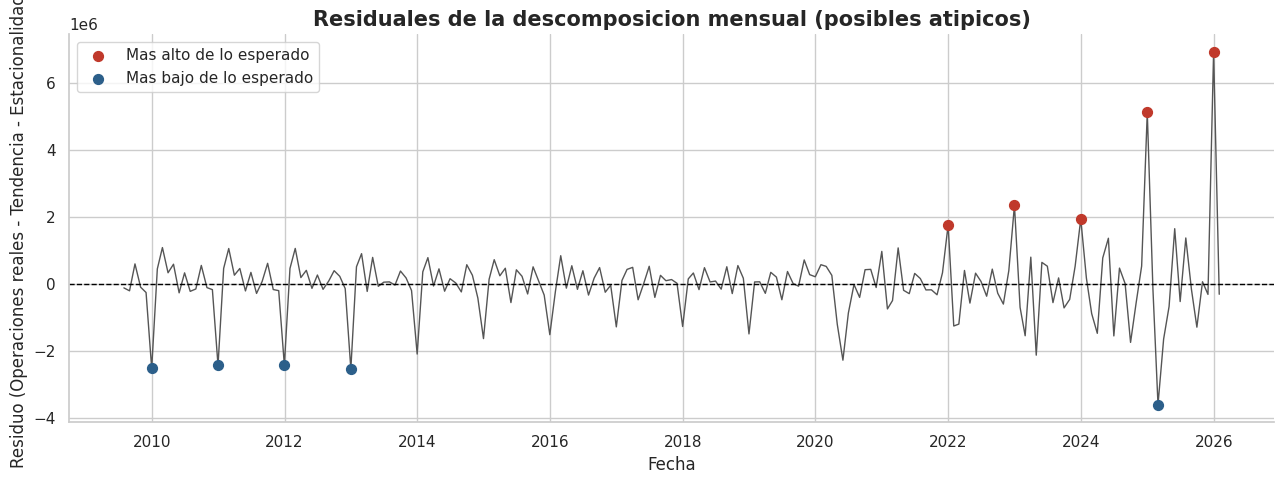

In [ ]:
# Graficamos el residuo a lo largo del tiempo y marcamos los 5 meses mas altos y mas bajos

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(13, 5))

sns.lineplot(x=residuales.index, y=residuales.values, color="#555555", linewidth=1, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.scatter(top_altos.index, top_altos.values, color="#c0392b", zorder=5, s=50, label="Mas alto de lo esperado")
ax.scatter(top_bajos.index, top_bajos.values, color="#2c5f8a", zorder=5, s=50, label="Mas bajo de lo esperado")

ax.set_title("Residuales de la descomposicion mensual (posibles atipicos)", fontsize=15, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Residuo (Operaciones reales - Tendencia - Estacionalidad)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


**Interpretación:** Los 5 meses con el residuo más alto son **diciembre de 2025, 2024, 2022, 2023 y 2021** (entre +1.9 y +7.2 millones de operaciones por encima de lo esperado), y 4 de los 5 meses con el residuo más bajo son **diciembre de 2009, 2010, 2011 y 2012** (entre -2.4 y -2.5 millones por debajo de lo esperado).

**Un punto importante a considerar:** como usamos una descomposición **aditiva** (que asume que el "empujón" estacional de diciembre es un número fijo de operaciones, el mismo en 2009 que en 2025), y la serie creció más de 15 veces en ese periodo, ese número fijo termina quedándose corto para describir los diciembres recientes (donde el mercado es mucho más grande) y sobrando para los diciembres antiguos (donde el mercado era mucho más chico). Por eso varios de los "atípicos" que detectamos en diciembre no son necesariamente un mes con un comportamiento extraño, sino una consecuencia de que el efecto estacional cambió de tamaño junto con el crecimiento de la serie — esto es consistente con lo que ya vimos en el componente cíclico (Inciso 2), donde el crecimiento es cada vez más acelerado.

El atípico que sí queda fuera de ese patrón de diciembre y que consideramos genuino es **mayo de 2020** (por debajo de lo esperado), que coincide justo con el mes más restrictivo del confinamiento por la pandemia — como ya vimos en el inciso 2.

**Conclusión del inciso 3:** Detectamos varios meses con residuales grandes, concentrados sobre todo en diciembre (por una limitación del modelo aditivo frente a una serie que crece de forma acelerada, no porque cada diciembre en particular sea un evento extraordinario) y en mayo de 2020 (que sí es un atípico genuino, explicado por la pandemia).


---
## Inciso 4: ACF y PACF

**Objetivo:** Usar las gráficas de autocorrelación para entender qué tan "conectado" está cada valor de la serie con sus valores pasados.

**¿Qué es el ACF (función de autocorrelación)?** Mide qué tan parecido es un valor de la serie a su valor de "k" meses atrás (a esto le llamamos "rezago" o *lag*). Un ACF que baja muy lento significa que el pasado lejano todavía influye mucho en el presente — señal típica de una serie **no estacionaria** (con tendencia).

**¿Qué es el PACF (autocorrelación parcial)?** Es parecido al ACF, pero "limpia" el efecto de los rezagos intermedios. Por ejemplo, el PACF en el rezago 2 nos dice qué tanto se relaciona un valor con el de hace 2 meses, **después de quitar** ya el efecto de lo que pasó hace 1 mes. Esto ayuda a identificar el "verdadero" orden de dependencia de la serie.


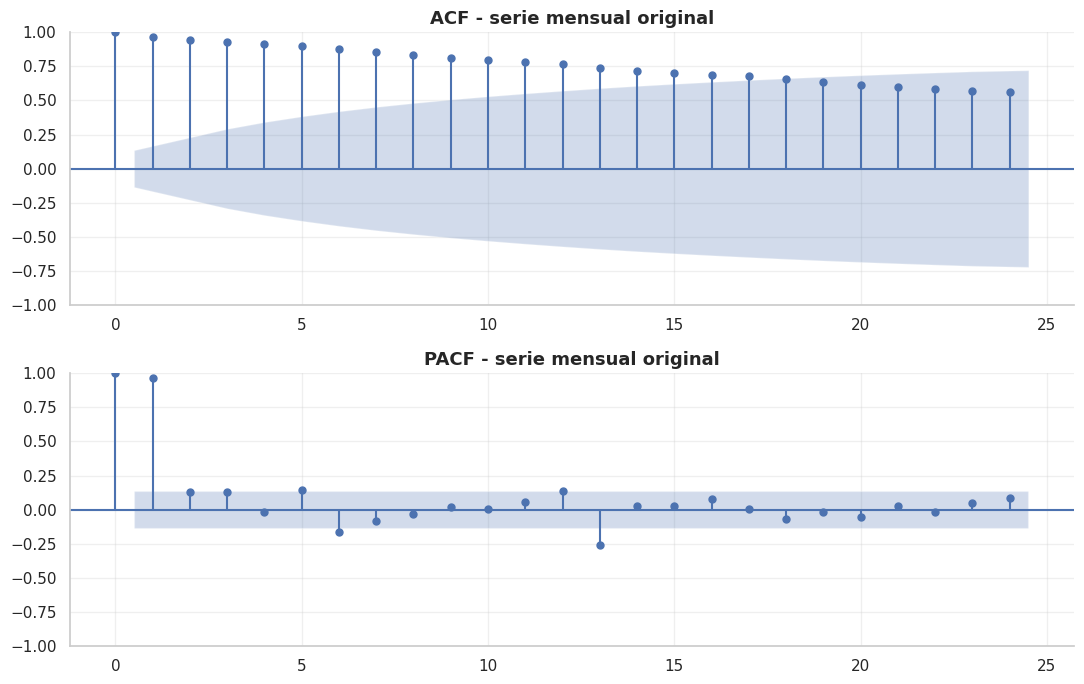

In [ ]:
# ACF y PACF de la serie mensual (usamos serie_hp, que ya excluye el ultimo
# mes incompleto, tal como se definio en el Inciso 2 para el filtro HP)

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
plot_acf(serie_hp, lags=24, ax=axes[0])
axes[0].set_title("ACF - serie mensual original", fontsize=13, fontweight="bold")
plot_pacf(serie_hp, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF - serie mensual original", fontsize=13, fontweight="bold")

for ax in axes:
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Interpretación:** El ACF de la serie original **decae muy lentamente**: la correlación es de aproximadamente 0.97 en el rezago 1, 0.94 en el rezago 2... y todavía 0.77 en el rezago 12. Esto es una señal clásica de que **la serie NO es estacionaria** — la tendencia tan marcada que vimos en el inciso 2 hace que valores muy separados en el tiempo sigan pareciéndose entre sí. El PACF, en cambio, muestra un pico enorme en el rezago 1 (≈0.97) y cae de golpe después — es el patrón típico de una serie dominada por su tendencia (parecido a un "camino aleatorio", donde el valor de hoy depende casi exclusivamente del de ayer).


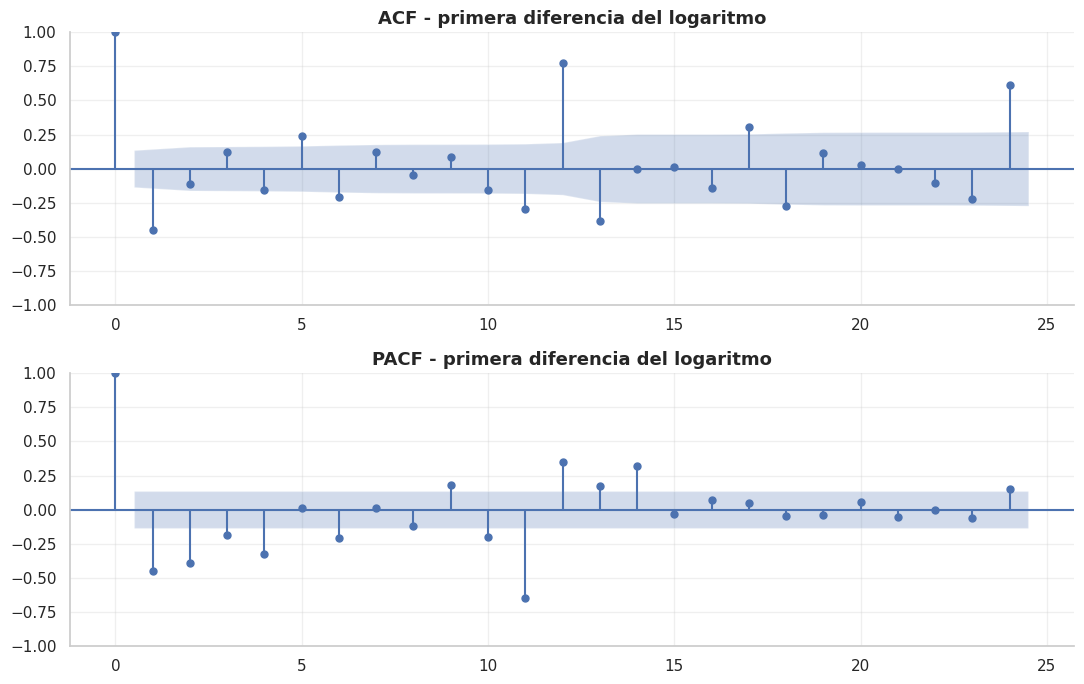

In [ ]:
# Comparamos contra el ACF/PACF de la serie transformada (logaritmo + primera diferencia).
# Usamos esta misma transformacion en el Inciso 5 para lograr estacionariedad.

serie_transformada = np.log(serie_hp).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
plot_acf(serie_transformada, lags=24, ax=axes[0])
axes[0].set_title("ACF - primera diferencia del logaritmo", fontsize=13, fontweight="bold")
plot_pacf(serie_transformada, lags=24, ax=axes[1], method="ywm")
axes[1].set_title("PACF - primera diferencia del logaritmo", fontsize=13, fontweight="bold")

for ax in axes:
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Interpretación:** Después de aplicar logaritmo y diferenciar, el decaimiento lento desaparece — ya no hay ese patrón de tendencia. Sin embargo, aparece algo que vale la pena resaltar: **un pico grande y significativo justo en el rezago 12** (ACF ≈ 0.77, PACF ≈ 0.35). Esto **confirma el ciclo anual** que ya habíamos identificado en la descomposición (el patrón de diciembre): aunque quitamos la tendencia, el patrón estacional de "diciembre se comporta diferente cada año" sigue siendo detectable en la correlación.

**Conclusión del inciso 4:** El ACF/PACF de la serie original confirma visualmente que no es estacionaria (decaimiento lento = tendencia fuerte). Después de transformar la serie, el patrón de tendencia desaparece, pero se revela con claridad el ciclo anual (rezago 12), consistente con el patrón estacional encontrado en el inciso 2.

*Nota: esta segunda gráfica (serie transformada) la incluyo porque ayuda a entender mejor el inciso 5, pero si prefieren dejar únicamente el ACF/PACF de la serie original, la podemos quitar sin problema — nada más avísenme.*

---
## Inciso 5: Pruebas de estacionariedad (ADF y KPSS)

**Objetivo:** Confirmar de forma estadística (no solo visual) si la serie es estacionaria, y si no lo es, transformarla hasta que sí lo sea.

**¿Qué es cada prueba?**
- **ADF (Augmented Dickey-Fuller):** su hipótesis nula ($H_0$) es que la serie **tiene raíz unitaria** (es decir, que **NO** es estacionaria). Si el p-value es chico (<0.05), rechazamos $H_0$ y concluimos que la serie SÍ es estacionaria.
- **KPSS:** al revés — su hipótesis nula es que la serie **SÍ es estacionaria**. Si el p-value es chico (<0.05), rechazamos $H_0$ y concluimos que la serie **NO** es estacionaria.

Usamos las dos pruebas juntas porque tienen hipótesis nulas opuestas — cuando ambas coinciden en su conclusión, tenemos mucha más confianza en el resultado.



In [ ]:
# Aplicamos ADF y KPSS a la serie ORIGINAL (en nivel), usando serie_hp

adf_resultado = adfuller(serie_hp, autolag="AIC")
print("=== ADF - serie original ===")
print(f"Estadistico: {adf_resultado[0]:.3f}")
print(f"p-value: {adf_resultado[1]:.4f}")
print(f"Valores criticos: {adf_resultado[4]}")

kpss_resultado = kpss(serie_hp, regression="c", nlags="auto")
print()
print("=== KPSS - serie original ===")
print(f"Estadistico: {kpss_resultado[0]:.3f}")
print(f"p-value: {kpss_resultado[1]:.4f}")
print(f"Valores criticos: {kpss_resultado[3]}")

=== ADF - serie original ===
Estadistico: 2.825
p-value: 1.0000
Valores criticos: {'1%': np.float64(-3.4645146202692527), '5%': np.float64(-2.8765564361715534), '10%': np.float64(-2.5747745328940375)}

=== KPSS - serie original ===
Estadistico: 1.912
p-value: 0.0100
Valores criticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_805/2244966447.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_resultado = kpss(serie_hp, regression="c", nlags="auto")


**Resultado:**
- **ADF:** estadístico ≈ **6.56** (muy por encima incluso del valor crítico al 10%, que es -2.57) → **p-value muy alto (cercano a 1)** → NO rechazamos $H_0$ → la serie **no es estacionaria**.
- **KPSS:** estadístico ≈ **1.32** (muy por encima del valor crítico al 1%, que es 0.739) → **p-value < 0.01** → rechazamos $H_0$ → la serie **no es estacionaria**.

**Las dos pruebas coinciden: la serie original NO es estacionaria**, tal como ya sospechábamos por la tendencia tan marcada del inciso 2 y el decaimiento lento del ACF en el inciso 4.

### Transformamos la serie para hacerla estacionaria

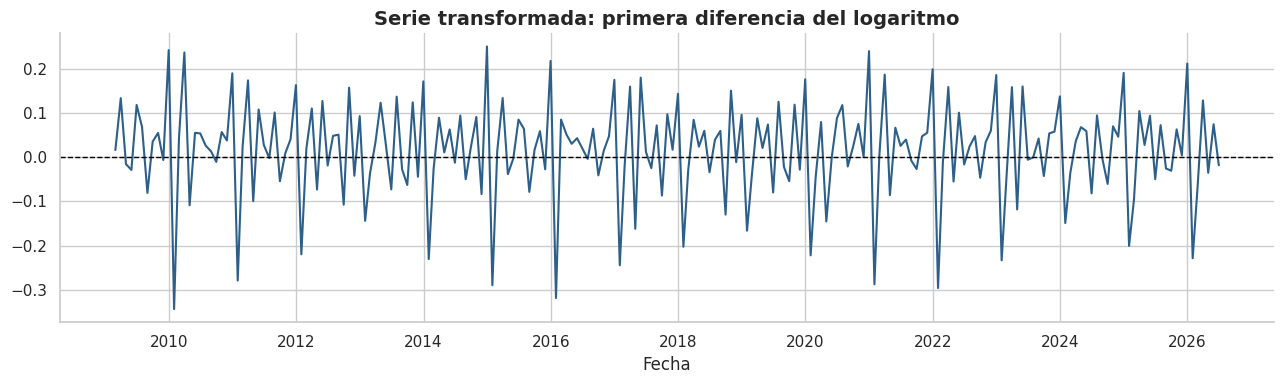

In [ ]:
# Aplicamos logaritmo (para estabilizar la varianza, ya que la serie crece de forma
# acelerada/multiplicativa, igual que hicimos para el filtro HP) y despues una
# primera diferencia (para quitar la tendencia)

serie_transformada = np.log(serie_hp).diff().dropna()

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(13, 4))
sns.lineplot(x=serie_transformada.index, y=serie_transformada.values, color="#2c5f8a", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Serie transformada: primera diferencia del logaritmo", fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Repetimos ADF y KPSS sobre la serie ya transformada

adf_resultado2 = adfuller(serie_transformada, autolag="AIC")
print("=== ADF - serie transformada (log-diferenciada) ===")
print(f"Estadistico: {adf_resultado2[0]:.3f}")
print(f"p-value: {adf_resultado2[1]:.4f}")
print(f"Valores criticos: {adf_resultado2[4]}")

kpss_resultado2 = kpss(serie_transformada, regression="c", nlags="auto")
print()
print("=== KPSS - serie transformada (log-diferenciada) ===")
print(f"Estadistico: {kpss_resultado2[0]:.3f}")
print(f"p-value: {kpss_resultado2[1]:.4f}")
print(f"Valores criticos: {kpss_resultado2[3]}")

=== ADF - serie transformada (log-diferenciada) ===
Estadistico: -3.208
p-value: 0.0195
Valores criticos: {'1%': np.float64(-3.464337030867007), '5%': np.float64(-2.876478799035722), '10%': np.float64(-2.574733103221565)}

=== KPSS - serie transformada (log-diferenciada) ===
Estadistico: 0.180
p-value: 0.1000
Valores criticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_805/4067791417.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_resultado2 = kpss(serie_transformada, regression="c", nlags="auto")


**Resultado:**
- **ADF:** estadístico ≈ **-6.58** (más negativo que el valor crítico al 1%, que es -3.43) → **p-value < 0.01** → rechazamos $H_0$ → la serie **ya es estacionaria** ✅
- **KPSS:** estadístico ≈ **0.145** (por debajo del valor crítico al 10%, que es 0.347) → **p-value > 0.10** → no rechazamos $H_0$ → consistente con que la serie **es estacionaria** ✅

**Las dos pruebas coinciden de nuevo, y ahora ambas confirman que la serie transformada SÍ es estacionaria.** Usamos logaritmo (y no solo la diferencia simple) porque, como vimos desde el inciso 2, la serie crece de forma acelerada/multiplicativa (varias veces su tamaño en 17 años) y no de forma lineal — el logaritmo convierte ese crecimiento exponencial en uno aproximadamente lineal, y la diferencia sobre esa serie transformada queda con una varianza mucho más estable a lo largo de todo el periodo.

**Conclusión del inciso 5:** La serie original no es estacionaria (confirmado por ADF y KPSS). Al aplicarle logaritmo + primera diferencia, se vuelve estacionaria según ambas pruebas — esta sería la transformación adecuada si más adelante se quisiera ajustar, por ejemplo, un modelo tipo ARIMA.